In [14]:
# !python -m pip install kagglehub
print("finish")

finish


In [15]:
# Impor dependences

import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


print("Continue!")

Continue!


In [16]:
import kagglehub
from kagglehub import KaggleDatasetAdapter


# definine file inside the dataset
file_path = "Churn_Modelling.csv"

# loading dataset as pandas df
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "adammaus/predicting-churn-for-bank-customers",
    file_path
)

cust_churn_data = df.copy()
cust_churn_data.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## BASIC DATA OVERVIEW

In [17]:


print("=" * 70)
print("DATA INFORMATION")
print("=" * 70)

# data shape
print(f"Shape: {cust_churn_data.shape}")
print(f"Dataset has {cust_churn_data.shape[0]} rows and {cust_churn_data.shape[1]} columns")

print("\n\n\n======================check for data points distributions====================")
print(cust_churn_data['Exited'].value_counts())

# column types and missing values
print("\n\n\nData Types and Missing Values:")
print(cust_churn_data.info())

# check basic statistics for numerical columns
print("\n check basic statistics for numerical columns")

cust_churn_data.describe()

DATA INFORMATION
Shape: (10000, 14)
Dataset has 10000 rows and 14 columns



======================check for data points distributions====================
Exited
0    7963
1    2037
Name: count, dtype: int64



Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  E

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## CHECK FOR IMBALANCE IN TARGET VARIABLE


TARGET VARIABLE ANALYSIS (Exited Column)
Customers who stayed (0): 7963 (79.6%)
Customers who churned (1): 2037 (20.4%)


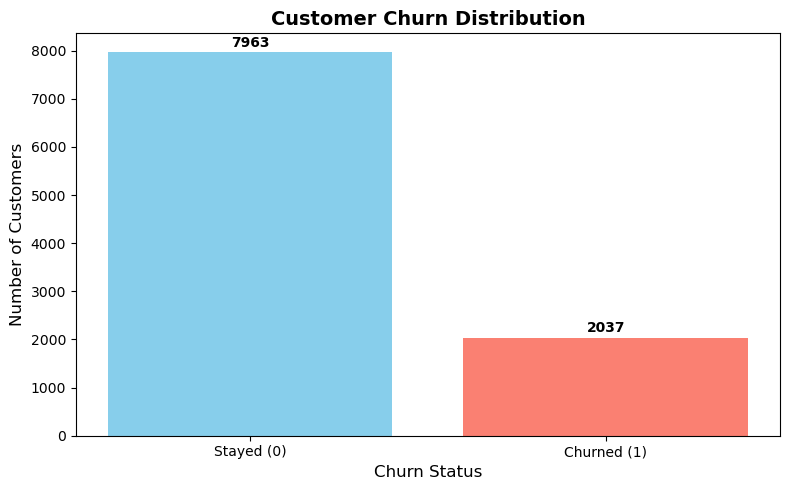

In [18]:



print("\n" + "=" * 70)
print("TARGET VARIABLE ANALYSIS (Exited Column)")
print("=" * 70)

# Count churned vs non-churned customers
churn_counts = cust_churn_data['Exited'].value_counts()
churn_percentages = cust_churn_data['Exited'].value_counts(normalize=True) * 100

print(f"Customers who stayed (0): {churn_counts[0]} ({churn_percentages[0]:.1f}%)")
print(f"Customers who churned (1): {churn_counts[1]} ({churn_percentages[1]:.1f}%)")

# Visualize the imbalance
plt.figure(figsize=(8, 5))
bars = plt.bar(['Stayed (0)', 'Churned (1)'], churn_counts.values, color=['skyblue', 'salmon'])
plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Add count labels on top of bars
for bar, count in zip(bars, churn_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             str(count), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig("saved_images/Customer_Churn_Distribution.png", dpi=300)
plt.show()

## EXPLORE KEY CATEGORICAL VARIABLES



CATEGORICAL VARIABLE ANALYSIS


<Figure size 1000x500 with 0 Axes>

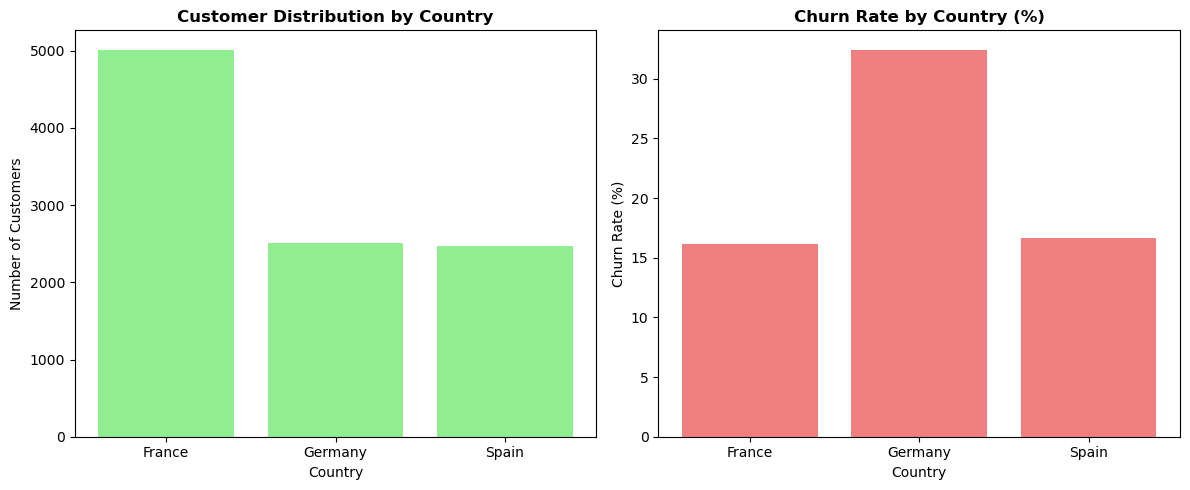

In [19]:
print("\n\n" + "=" * 70)
print("CATEGORICAL VARIABLE ANALYSIS")
print("=" * 70)

# Visualize Geography distribution with churn
plt.figure(figsize=(10, 5))

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Geography distribution
geo_counts = cust_churn_data['Geography'].value_counts()
ax1.bar(geo_counts.index, geo_counts.values, color='lightgreen')
ax1.set_title('Customer Distribution by Country', fontweight='bold')
ax1.set_xlabel('Country')
ax1.set_ylabel('Number of Customers')

# Plot 2: Churn rate by Geography
churn_by_geo = cust_churn_data.groupby('Geography')['Exited'].mean() * 100
ax2.bar(churn_by_geo.index, churn_by_geo.values, color='lightcoral')
ax2.set_title('Churn Rate by Country (%)', fontweight='bold')
ax2.set_xlabel('Country')
ax2.set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig("saved_images/country_distribution_and_churn_rate.png", dpi=300)
plt.show()

## EXPLORE KEY NUMERICAL VARIABLES


NUMERICAL VARIABLE ANALYSIS
Correlation with Churn:
  CreditScore: -0.027
  Age: 0.285
  Tenure: -0.014
  Balance: 0.119
  EstimatedSalary: 0.012



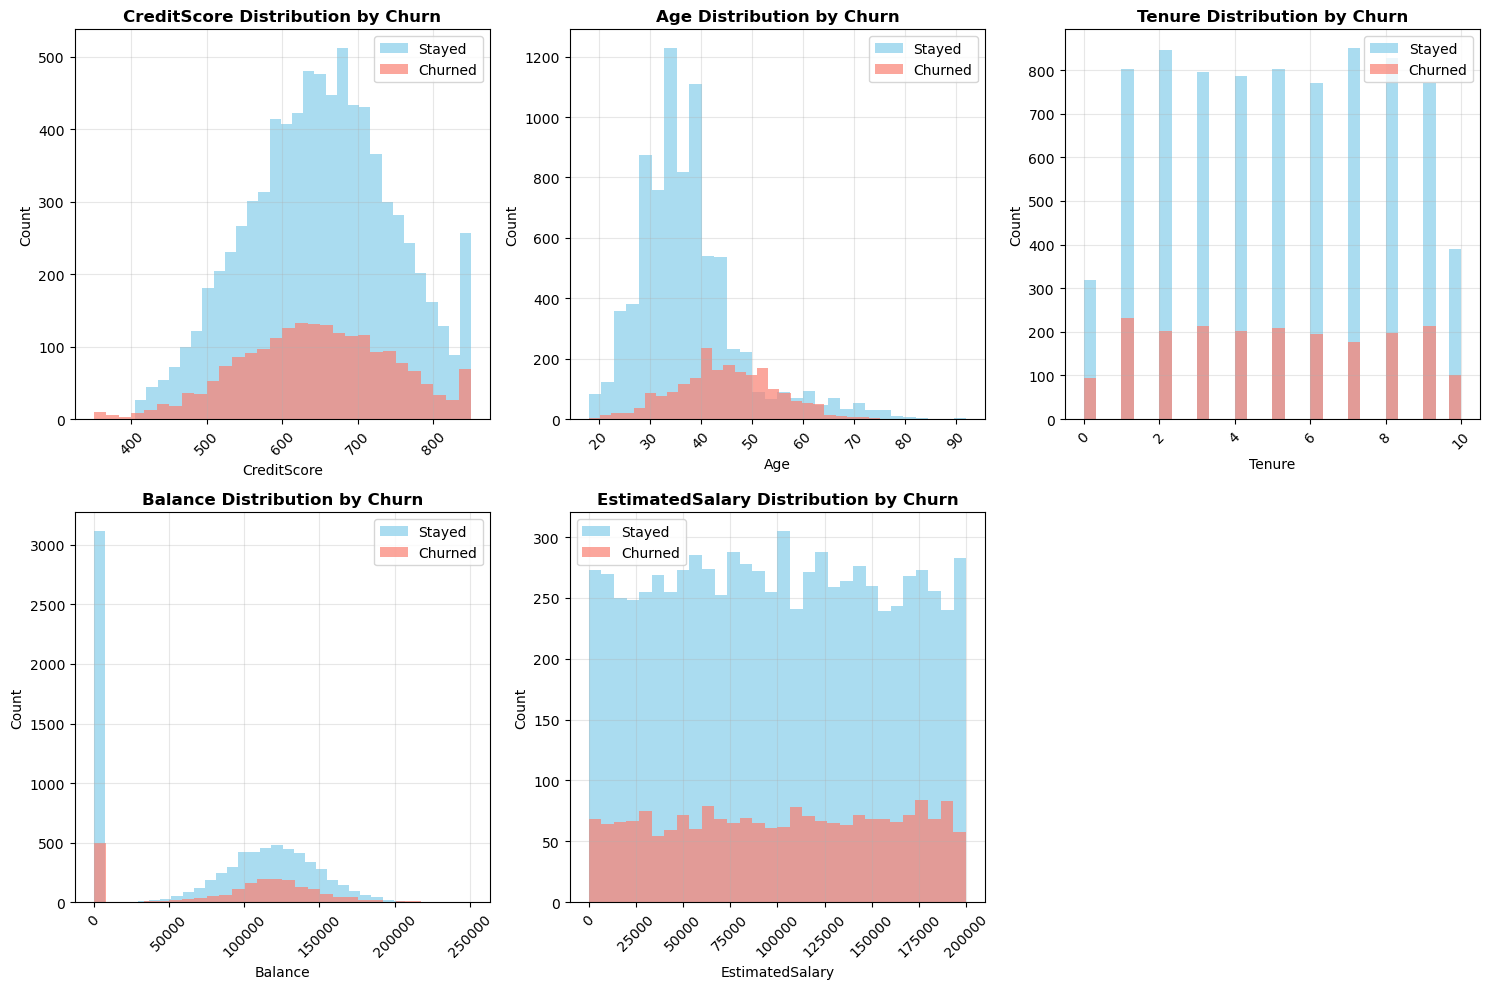

In [20]:
print("\n" + "=" * 70)
print("NUMERICAL VARIABLE ANALYSIS")
print("=" * 70)

numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

print("Correlation with Churn:")

for col in numerical_cols:
    correlation = cust_churn_data[col].corr(cust_churn_data['Exited'])
    print(f"  {col}: {correlation:.3f}")

# put space
print()
# visualize distributions of numerical variabls
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols[:5]):  # Only first 5 for display
    # Create separate distributions for churned vs non-churned
    stayed = cust_churn_data[cust_churn_data['Exited'] == 0][col]
    churned = cust_churn_data[cust_churn_data['Exited'] == 1][col]
    
    axes[idx].hist(stayed, alpha=0.7, label='Stayed', bins=30, color='skyblue')
    axes[idx].hist(churned, alpha=0.7, label='Churned', bins=30, color='salmon')
    axes[idx].set_title(f'{col} Distribution by Churn', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].set_ylabel('Count')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

# hide empty subplot if any
if len(numerical_cols) < 6:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

### Fom the Above figure

### 1 Credit Score Distribution

Customers who churn tend to have `slightly lower credit scores` compared to those who stay, suggesting that weaker financial profiles may be associated with higher churn risk.


### 2 Age Distribution

Churn is most concentrated among `middle-aged customers (approximately 35–55 years)`, indicating that this group is more likely to switch banks, possibly due to better offers or changing financial needs.


### 3 Tenure Distribution

Customers leave the bank `no matter how long they have been customers`.This means being with the bank for `a long time` does not guarantee loyalty.

Customer churn occurs `across all tenure levels`, showing that both new and long-term customers are at risk and tenure alone is not a strong indicator of loyalty.



### 4 Balance Distribution

Customers with `higher account balances show a higher likelihood of churn`, implying that financially active customers may move their funds to competitors offering more attractive benefits.


### 5 Estimated Salary Distribution

The churn and non-churn distributions overlap heavily across all salary levels, indicating that `estimated salary has minimal influence on churn behavior`.


## CHECK FOR MISSING VALUES

In [21]:

print("\n" + "=" * 70)
print("MISSING VALUES CHECK")
print("=" * 70)

missing_values = cust_churn_data.isnull().sum()
missing_values ## no missing values


MISSING VALUES CHECK


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

##  AGE ANALYSIS 


AGE ANALYSIS


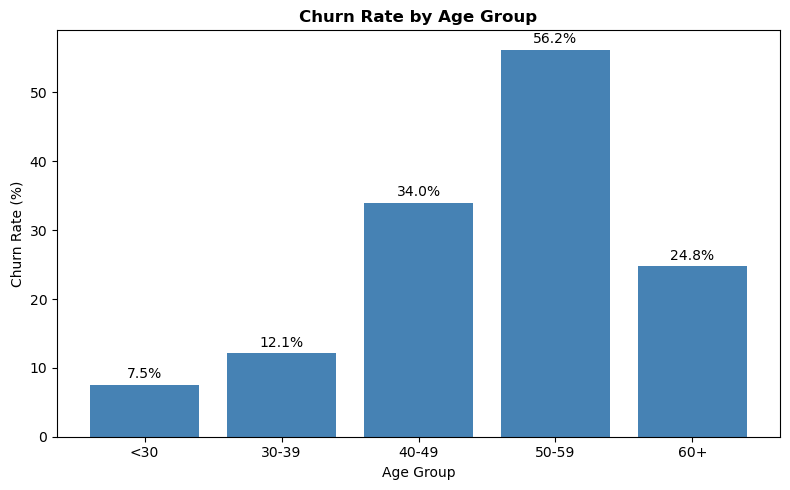

In [22]:
print("\n" + "=" * 70)
print("AGE ANALYSIS")
print("=" * 70)

# Create age groups
cust_churn_data['AgeGroup'] = pd.cut(cust_churn_data['Age'], 
                                     bins=[0, 30, 40, 50, 60, 100],
                                     labels=['<30', '30-39', '40-49', '50-59', '60+'])

# Calculate churn rate by age group
age_churn = cust_churn_data.groupby('AgeGroup')['Exited'].mean() * 100


# Visualize age group churn
plt.figure(figsize=(8, 5))
bars = plt.bar(age_churn.index.astype(str), age_churn.values, color='steelblue')
plt.title('Churn Rate by Age Group', fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')

# Add percentage labels
for bar, rate in zip(bars, age_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{rate:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.savefig("saved_images/Churn_Rate_by_Age_Group.png", dpi=300)
plt.show()

## SAVE THE CLEAN DATAFRAME TO data DIRECTORY

In [23]:
cust_churn_data.to_csv('data/cust_churn_data.csv', index=False)


### Create test dataset

In [24]:
df = pd.read_csv("data/cust_churn_data.csv")
data = df.copy()
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,40-49
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,40-49
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,40-49
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,30-39
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,40-49


In [25]:
# only 50 rows
# data.drop('Exited', axis=1, inplace=True)
data[data['RowNumber'] <=50].to_csv("test_data/test_churn_data.csv", index=False)


In [28]:
data_df = pd.read_csv("test_data/test_churn_data.csv")
data_df.shape

(50, 15)